# Day 3.2 — Context Budgets and Compaction — You Build It
A history that grows for ever costs more than it is worth, so the program decides what to drop.
**Compaction** keeps the newest turns word-for-word and replaces older ones with a bounded summary.
This is the day's one hands-on exercise: write it, check it, then read the reference solution.

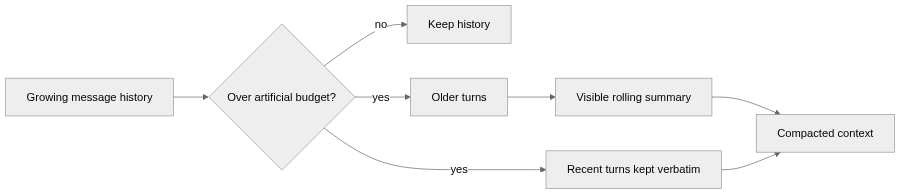

*D09 — over-budget history: older turns become a visible summary, recent turns stay verbatim*

### Step 1 — Count the cost

Providers bill per token. A rough classroom rule is *four characters ≈ one token* — approximate
on purpose: we want a number on screen, not an exact bill.

In [ ]:
def estimate_tokens(text):
    """A visible approximation; a provider's tokenizer is more exact."""
    return max(1, (len(text) + 3) // 4)

def total_tokens(messages):
    """Estimated size of a whole message list, so BEFORE/AFTER is easy to print."""
    return sum(estimate_tokens(m["content"]) for m in messages)

sample = "The project deadline is 14 March and it cannot move."
print("text            :", sample)
print("characters      :", len(sample))
print("estimated tokens:", estimate_tokens(sample))

### Step 2 — A conversation that has been running a while

Ten exchanges. Note where the most valuable fact in the whole conversation sits: the deadline,
in the very first turn.

In [ ]:
PAIRS = [
    ("My final year project is called Aurora and the hard deadline is 14 March; it cannot move.",
     "Recorded: project Aurora, hard deadline 14 March."),
    ("Every measurement in the report must be written in millimetres, never in inches.",
     "Understood, all measurements will use millimetres."),
    ("The lab session moved from Tuesday morning to Thursday afternoon this week.",
     "Noted, the lab session is now on Thursday afternoon."),
    ("My mentor prefers short emails, at most five sentences, with a clear subject line.",
     "Understood, emails to your mentor will stay under five sentences."),
    ("Please keep every progress summary under one hundred words.",
     "Agreed, progress summaries will stay under one hundred words."),
    ("The sensor board we ordered arrives next Monday, so testing starts after that.",
     "Noted, testing starts after the sensor board arrives next Monday."),
    ("Team meetings should never be scheduled before ten in the morning.",
     "Understood, no meetings before ten."),
    ("The report template asks for a one page abstract at the front.",
     "Noted, a one page abstract goes at the front."),
    ("Please use the university logo only on the cover page of the report.",
     "Understood, the logo stays on the cover page."),
    ("Remind me which measurement unit we agreed on for the report.",
     "Millimetres, as you asked earlier."),
]

long_history = []
for user_text, assistant_text in PAIRS:
    long_history.append({"role": "user", "content": user_text})
    long_history.append({"role": "assistant", "content": assistant_text})

BUDGET = 200                     # artificially small so the whole lesson fits on screen

print("messages        :", len(long_history))
print("estimated tokens:", total_tokens(long_history))
print("budget          :", BUDGET, "-> over budget by",
      total_tokens(long_history) - BUDGET, "tokens")
print("oldest message  :", long_history[0]["content"])

### Step 3 — Two helpers you are given

`key_fact` shortens one message; `summarize_messages` packs as many of those as a budget allows,
newest first, and states how many turns it dropped. No model is called, so nothing is invented —
and nothing is understood either.

In [ ]:
SUMMARY_PREFIX = "Earlier conversation summary (rule-based, lossy):"

def key_fact(message, max_words=12):
    """One message -> one short 'role: fact' line. It keeps the first few words, nothing smarter."""
    words = message["content"].split()
    fact = " ".join(words[:max_words]) + (" ..." if len(words) > max_words else "")
    return f"{message['role']}: {fact}"

def summarize_messages(messages, summary_budget):
    """Pack shortened facts, NEWEST FIRST, into one system message inside summary_budget tokens."""
    lines, used = [], estimate_tokens(SUMMARY_PREFIX) + 10      # header + room for the "dropped" note
    for message in reversed(messages):
        fact = key_fact(message)
        if used + estimate_tokens(fact) + 1 > summary_budget:
            break                                               # budget full: the oldest turns are lost
        lines.append(fact)
        used += estimate_tokens(fact) + 1
    lines.reverse()
    dropped = len(messages) - len(lines)
    header = [SUMMARY_PREFIX] + ([f"- ({dropped} older turns dropped)"] if dropped else [])
    return {"role": "system", "content": "\n".join(header + [f"- {line}" for line in lines])}

print(key_fact(long_history[0]))
print()
print(summarize_messages(long_history[:6], summary_budget=60)["content"])

### Your turn — write `compact_history`

```python
compact_history(messages, budget=200) -> list[dict]
```

Rules: never modify the input; if the history already fits, return a copy unchanged; otherwise
give the summary `budget // 3` tokens and the recent turns the rest, keep whole messages from the
newest backwards (at least one), summarise the rest with `summarize_messages`, and never return
something larger than you started with.

In [ ]:
def compact_history(messages, budget=200):
    """YOUR TURN: return [summary, *recent turns] fitting inside `budget` estimated tokens."""
    # TODO: if total_tokens(messages) <= budget -> return a copy, unchanged
    # TODO: summary_budget = max(16, budget // 3); recent_budget = budget - summary_budget
    # TODO: walk backwards keeping whole messages while they fit recent_budget (keep at least one)
    # TODO: removed = everything older than what you kept
    # TODO: return [summarize_messages(removed, summary_budget), *kept]
    # TODO: if that is not smaller than the original, return just the kept turns
    raise NotImplementedError("write the compaction step")

print("compact_history stub defined - fill in the TODOs, then run the check below")

### Behavioural check

It prints a hint instead of failing while your function is unfinished.

In [ ]:
def run_compaction_checks():
    short = [{"role": "user", "content": "one short turn"}]
    kept = compact_history(short, budget=BUDGET)
    assert kept == short and kept is not short, "a history inside the budget is returned as an unchanged COPY"

    before, count_before = total_tokens(long_history), len(long_history)
    result = compact_history(long_history, budget=BUDGET)
    assert total_tokens(long_history) == before and len(long_history) == count_before, "do not modify the input"
    assert total_tokens(result) < before, "compaction must make the history SMALLER"
    assert total_tokens(result) <= BUDGET, f"still over budget: {total_tokens(result)} > {BUDGET}"
    assert result[0]["role"] == "system" and result[0]["content"].startswith(SUMMARY_PREFIX), "summary comes first"
    assert result[1:] == long_history[-(len(result) - 1):], "recent turns must be kept VERBATIM"
    print("PASS: bounded, smaller, summary first, recent turns verbatim, input untouched")

try:
    run_compaction_checks()
except NotImplementedError:
    print("Not implemented yet. Fill in compact_history above, or read the reference solution below and re-run this cell.")

### Reference solution

Read it line by line even if your check passed. **This version is used for the rest of the day.**

In [ ]:
# --- Reference solution ------------------------------------------------------------
def compact_history(messages, budget=200):
    before = total_tokens(messages)
    if before <= budget:
        return messages[:]                       # already fits: hand back a copy, unchanged

    summary_budget = max(16, budget // 3)        # the summary can never grow into a second transcript
    recent_budget = budget - summary_budget

    kept, used = [], 0
    for message in reversed(messages):           # newest first: recent turns matter most
        cost = estimate_tokens(message["content"])
        if kept and used + cost > recent_budget:
            break
        kept.append(message)                     # always keep at least the newest message
        used += cost
    kept.reverse()

    removed = messages[: len(messages) - len(kept)]
    if not removed:
        return kept
    compacted = [summarize_messages(removed, summary_budget), *kept]
    return compacted if total_tokens(compacted) < before else kept   # never return something bigger

run_compaction_checks()

### Step 4 — Measure it, then read what it produced

Compaction must never be invisible: print the size before and after, the summary, and the turns
that survived word-for-word.

In [ ]:
compacted = compact_history(long_history, budget=BUDGET)
before, after = total_tokens(long_history), total_tokens(compacted)

print(f"BEFORE: {len(long_history):>2} messages, {before} tokens")
print(f"AFTER : {len(compacted):>2} messages, {after} tokens  "
      f"({100 * (before - after) // before}% smaller, fits budget: {after <= BUDGET})")

print()
print("--- the summary message that replaced the older turns ---")
print(compacted[0]["content"])
print()
print("--- kept verbatim ---")
for message in compacted[1:]:
    print(f"{message['role']:>9}: {message['content']}")

### Step 5 — Name what was lost

Ask the compacted history two questions. One fact survived in the recent turns; the other was in
the first turn and is gone. Nothing in the code knew that "14 March" mattered more than "Understood".

In [ ]:
print("deadline still present in the text?", any("14 March" in m["content"] for m in compacted))

for query in ["Remind me: which unit did we agree on for the report?",
              "Remind me: what is the hard deadline?"]:
    print()
    print("Q:", query)
    print("A:", chat(compacted + [{"role": "user", "content": query}])["content"])

print()
print("A MODEL summary would reword the old turns and might well keep '14 March' - at the cost of")
print("an extra call, non-determinism, and its own quiet omissions. Both kinds of summary are lossy.")
print("Conclusion: a fact you must not lose does not belong in a summary. It belongs in a store (3.3).")

### Step 6 — What a bigger budget buys

Same history, three budgets. More budget keeps more turns *and* funds a longer summary — paid for
on every later call.

In [ ]:
for budget in (120, 200, 280):
    result = compact_history(long_history, budget=budget)
    summarised = result[0]["content"].startswith(SUMMARY_PREFIX)
    facts = [line for line in result[0]["content"].splitlines()
             if summarised and line.startswith("- ") and "dropped)" not in line]
    print(f"budget={budget:>3} -> {total_tokens(result):>3} tokens, {len(result):>2} messages, "
          f"{len(facts)} old facts kept in the summary")
print("\nAt the tightest budget the summary shrinks to nothing but an admission that turns were lost.")

### Checkpoint

**1. Why does compaction shrink the history instead of moving the old text under a new heading?**

<details><summary>Show answer</summary>

Because the summary has a budget of its own (`budget // 3`) and facts are packed newest-first until it is full. A "summary" that copies the old turns saves nothing and still costs tokens on every later call.

</details>

**2. Our summary is written by Python. What changes if a model writes it instead?**

<details><summary>Show answer</summary>

It compresses several turns into one sentence, so an old fact is likelier to survive — at the cost of a call, non-determinism, and its own quiet omissions. Lossy either way, which is why durable facts go into memory.

</details>

### Recap

- **Limitation seen:** a growing history broke the budget, and compacting it destroyed the deadline stated in the first turn.
- **Layer added:** a budgeted, printable compaction step between the history and the model call.
- **Evidence:** 20 over-budget messages became a summary plus recent turns inside 200 tokens, and afterwards the model could still name the unit but not the deadline.